In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
#1.	Загрузить датасет train.csv, вывести первые 10 строк.
df = pd.read_csv('titanic.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [37]:
#2.	Посмотреть типы данных и общую информацию (.info()).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
df.select_dtypes(include='object')

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,NaN,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [39]:
#3.	Подсчитать количество пропущенных значений в каждом столбце.
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
df = df.drop(columns='Cabin')

In [41]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [42]:
df['Age'] = df['Age'].astype(int)

In [43]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [44]:
#4.	Вывести статистику по числовым колонкам (.describe()).
df.describe().round()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.0,891.0,891.0,891.0,891.0,891.0
mean,446.0,0.0,2.0,29.0,1.0,0.0,32.0
std,257.0,0.0,1.0,13.0,1.0,1.0,50.0
min,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,224.0,0.0,2.0,22.0,0.0,0.0,8.0
50%,446.0,0.0,3.0,28.0,0.0,0.0,14.0
75%,668.0,1.0,3.0,35.0,1.0,0.0,31.0
max,891.0,1.0,3.0,80.0,8.0,6.0,512.0


In [45]:
#5.	Посчитать количество выживших / невыживших (значения Survived).
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [46]:
df['Survived'].value_counts(normalize=True).round(2)

,proportion
Survived,
0,0.62
1,0.38


In [47]:
df[['Sex', 'Survived']].value_counts()

,,count
Sex,Survived,
male,0,468
female,1,233
male,1,109
female,0,81


In [48]:
#7.	Рассчитать средний и медианный возраст пассажиров.
df['Age'].mean().round()

np.float64(29.0)

In [49]:
df['Age'].median()

28.0

In [50]:
#8.	Рассчитать средний возраст по полу.
df.groupby('Sex')['Age'].mean().round()

,Age
Sex,
female,28.0
male,30.0


In [51]:
#9.	Средняя стоимость билета по классам (Pclass).
df['Fare'].mean().round(2)

np.float64(32.2)

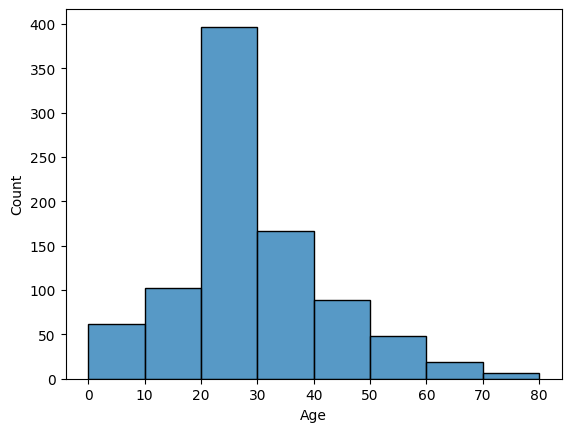

In [52]:
from numpy._core.defchararray import endswith
#10.	Построить гистограмму распределения возраста (Age).
sns.histplot(data=df, x='Age', bins=8)
plt.show()

In [53]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [54]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S
887,1,1,female,19,0,0,30.0000,S
888,0,3,female,28,1,2,23.4500,S
889,1,1,male,26,0,0,30.0000,C


In [55]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [56]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True).astype(int)

In [57]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22,1,0,7,0,1
1,1,1,1,38,1,0,71,0,0
2,1,3,1,26,0,0,7,0,1
3,1,1,1,35,1,0,53,0,1
4,0,3,0,35,0,0,8,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13,0,1
887,1,1,1,19,0,0,30,0,1
888,0,3,1,28,1,2,23,0,1
889,1,1,0,26,0,0,30,0,0


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaler = scaler.fit_transform(df.drop(columns='Survived'))

In [59]:
df.drop(columns='Survived')

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22,1,0,7,0,1
1,1,1,38,1,0,71,0,0
2,3,1,26,0,0,7,0,1
3,1,1,35,1,0,53,0,1
4,3,0,35,0,0,8,0,1
...,...,...,...,...,...,...,...,...
886,2,0,27,0,0,13,0,1
887,1,1,19,0,0,30,0,1
888,3,1,28,1,2,23,0,1
889,1,0,26,0,0,30,0,0


In [60]:
x = df_scaler
y = df['Survived']

In [61]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

In [63]:
log_model.fit(x_train, y_train)

LogisticRegression()

In [64]:
y_pred = log_model.predict(x_test)

In [65]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_test)

0.8100558659217877

In [66]:
import joblib

joblib.dump(log_model, 'mysite/titanic_model.pkl')
joblib.dump(scaler, 'titanic_scaler.pkl')

['titanic_scaler.pkl']

In [67]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22,1,0,7,0,1
1,1,1,1,38,1,0,71,0,0
2,1,3,1,26,0,0,7,0,1
3,1,1,1,35,1,0,53,0,1
4,0,3,0,35,0,0,8,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13,0,1
887,1,1,1,19,0,0,30,0,1
888,0,3,1,28,1,2,23,0,1
889,1,1,0,26,0,0,30,0,0


In [68]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')